# Select MgkPro solutions (Loop 3)

Loads the optimized solutions, builds an AnnData from them, and selects options with opposing butyzamide/TPO concentrations.

In [3]:
from pathlib import Path 
import os 
import sys
sys.path.insert(0, "../../../../../../shared_utils")
from experiment_utils import manual_filtering

import matplotlib.pyplot as plt 
import scanpy as sc
import numpy as np 
import pandas as pd
import scipy as sp 
import seaborn as sns
from tqdm import tqdm 
import copy
import math
import yaml
import fpsample
from scipy.spatial.distance import cdist

## Load solutions 

In [2]:
def load_pure_cell_type_solutions(
    path_to_results,
    paths,
    cell_types,
):

    path_to_results = Path(path_to_results)

    pure_cell_type_solution_dict = {
        cell_type: [] for cell_type in cell_types
    }

    for experiment_folder in tqdm(paths):

        cell_type_file_paths = path_to_results / experiment_folder

        if not cell_type_file_paths.exists():
            continue

        # Iterate through cell types
        for cell_type in os.listdir(cell_type_file_paths):

            if cell_type not in cell_types:
                continue

            config_exp_folders = cell_type_file_paths / cell_type

            if not config_exp_folders.is_dir():
                continue

            # Iterate through experiment configs
            for config_exp_folder in os.listdir(config_exp_folders):

                exp_folder = config_exp_folders / config_exp_folder

                if not exp_folder.is_dir():
                    continue

                # Check candidates.csv exists
                if "candidates.csv" not in os.listdir(exp_folder):
                    continue

                # uncertainty_path = (
                #     exp_folder
                #     / "uncertainty_annotation"
                #     / "candidates_with_uncertainties.csv"
                # )

                uncertainty_path = (
                    exp_folder
                    / "candidates.csv"
                )

                # Check uncertainty annotation exists
                if uncertainty_path.exists():

                    candidate_with_uncertainty_df = pd.read_csv(
                        uncertainty_path
                    )

                    candidate_with_uncertainty_df["run_name"] = [
                        Path(file).name
                        for file in candidate_with_uncertainty_df[
                            "cfg:paths:dump_dir"
                        ]
                    ]

                    pure_cell_type_solution_dict[cell_type].append(
                        candidate_with_uncertainty_df
                    )

    return pure_cell_type_solution_dict

## Read annotation file

In [16]:
ANNOTATION_CFG_FILE = "../../../../../../inverse/loss_guidance/config/annotation/bloodplus_loop3.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

ANNOTATION_CFG_FILE_BOUNDS = "../../../../../../inverse/loss_guidance/config/constraints/default_all_cols_loop3.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound = yaml.safe_load(fb)
ubound_dict, lbound_dict = annotation_cfg_bound["ubound_dict"],  annotation_cfg_bound["lbound_dict"]

# Collect per parameter bounds 
bounds = {}
for param in lbound_dict:
    bounds[param] = (lbound_dict[param], ubound_dict[param])

### Collect optimized samples 

In [17]:
path_to_results_post_loop3 = Path("../../../../../../project_folder/output/inverse/loss_guidance/bloodplus_inverse_fm_loop3")
paths_post_loop3 = os.listdir(path_to_results_post_loop3)

In [18]:
cell_types = ["late_MgkPro"]

In [19]:
raw_solutions_post_loop3 = load_pure_cell_type_solutions(
    path_to_results_post_loop3,
    paths_post_loop3,
    cell_types,
)

100%|██████████| 6/6 [00:07<00:00,  1.33s/it]


In [20]:
# Concatenate data frame 
raw_solutions_post_loop3 = {
    key: pd.concat(val, axis=0) for key, val in raw_solutions_post_loop3.items()
}

In [21]:
for col in raw_solutions_post_loop3["late_MgkPro"].columns:
    print(col)

Unnamed: 0
sample_id
gm-csf_[ng_ml]
tpo_[ng_ml]
sr1_[nm]
um171_[nm]
um729_[µm]
scf_[ng_ml]
butyzamide_[nm]
retinoic_acid_[µm]
ldl_[ng_ml]
il3_[ng_ml]
o2_[%]
days_of_culture
il7_[ng_ml]
mcsf_[ng_ml]
gm-csf_[ng_ml]:rescaled
tpo_[ng_ml]:rescaled
sr1_[nm]:rescaled
um171_[nm]:rescaled
um729_[µm]:rescaled
scf_[ng_ml]:rescaled
butyzamide_[nm]:rescaled
retinoic_acid_[µm]:rescaled
ldl_[ng_ml]:rescaled
il3_[ng_ml]:rescaled
o2_[%]:rescaled
days_of_culture:rescaled
il7_[ng_ml]:rescaled
mcsf_[ng_ml]:rescaled
loss
CD14Mono_prop
CD16Mono_prop
CyclingPro1_prop
CyclingPro2_prop
Early_GMP_prop
EosBasMast1_prop
EosBasMast2_prop
EosBasMast3_prop
EryPro_prop
GMP-Neutro_prop
GMP_cycling_prop
HSCs_prop
LMPP-CLP_prop
MLP_prop
MPP_prop
MPP_MgkEry_prop
MgKEryPro1_prop
MgKEryPro2_prop
ProB_prop
earlyMPP_prop
late_MgkPro_prop
preProB_prop
pre_cDC1_prop
pre_cDC2_prop
cfg:annotation:protocol_columns
cfg:annotation:protocol_obs_key_added
cfg:annotation:protocol_sep
cfg:annotation:one_hot_uns_key_added
cfg:annotation

### Initialize targets

Only 4 types were optimized 

In [22]:
# Cell type fractions
celltype_fraction = {"late_MgkPro": 0.02}

columns_of_interest = [
    'gm-csf_[ng_ml]',
    'tpo_[ng_ml]',
    'sr1_[nm]',
    'um171_[nm]',
    'um729_[µm]',
    'scf_[ng_ml]',
    'butyzamide_[nm]',
    'retinoic_acid_[µm]',
    'ldl_[ng_ml]',
    'il3_[ng_ml]',
    'o2_[%]',
    'days_of_culture',
    'run_name',
    'il7_[ng_ml]',
    'mcsf_[ng_ml]',
    "loss", 
    "target_ct_loss_std",
    "target_ct_loss_mean",
    "ct_prop_total_variance",
]

### Filter values

In [23]:
# Collect filtered and annotated data frames 
filtered_df, annotated_df = manual_filtering(
    raw_solutions_post_loop3,
    bounds=bounds,
    columns_to_keep=columns_of_interest, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=1, 
    protocol_cols=protocol_cols
)

In [24]:
# Filtered and unfiltered solutions 
for ct in filtered_df:
    print(f"Filtered {ct} number of solutions:", filtered_df[ct].shape[0])
    print(f"Unfiltered {ct} number of solutions:", raw_solutions_post_loop3[ct].shape[0], "\n")

Filtered late_MgkPro number of solutions: 8827
Unfiltered late_MgkPro number of solutions: 45350 



In [25]:
filtered_df["late_MgkPro"]["late_MgkPro_prop"]

9     0.999997
5     0.999994
35    0.999986
44    0.999986
22    0.999979
        ...   
42    0.020033
18    0.020021
19    0.020017
25    0.020011
18    0.020005
Name: late_MgkPro_prop, Length: 8827, dtype: float64

# Create an AnnData and plot solution 

In [27]:
adata_opt_solutions = sc.AnnData(X = filtered_df["late_MgkPro"].loc[:, protocol_cols])
adata_opt_solutions.var.index = protocol_cols
adata_opt_solutions.obs["uncertainty"] = filtered_df["late_MgkPro"]["target_ct_loss_std"].values
adata_opt_solutions.obs["late_MgkPro_proportions"] = filtered_df["late_MgkPro"]["late_MgkPro_prop"].values

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [28]:
sc.pp.log1p(adata_opt_solutions)
sc.tl.pca(adata_opt_solutions)
sc.pp.neighbors(adata_opt_solutions)
sc.tl.umap(adata_opt_solutions)

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


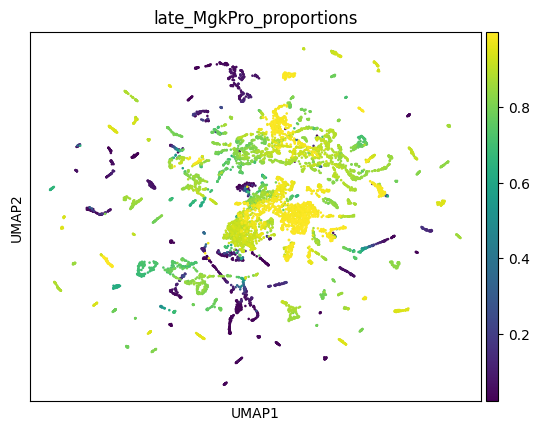

In [29]:
sc.pl.umap(adata_opt_solutions, color="late_MgkPro_proportions")

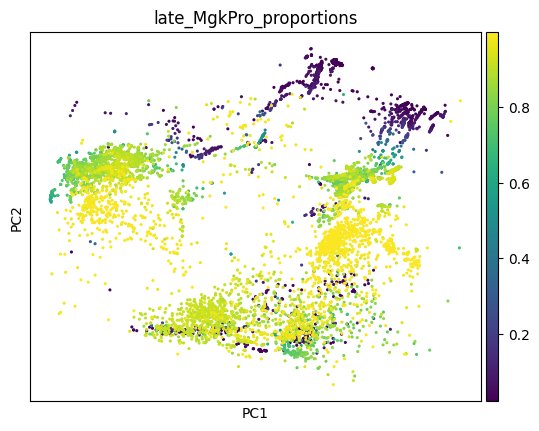

In [30]:
sc.pl.pca(adata_opt_solutions, color="late_MgkPro_proportions", s=20)

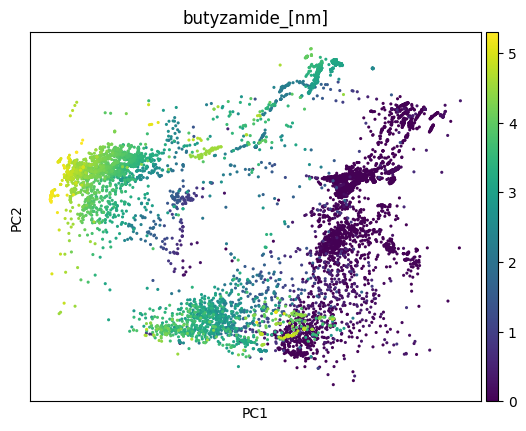

In [31]:
sc.pl.pca(adata_opt_solutions, color="butyzamide_[nm]", s=20)

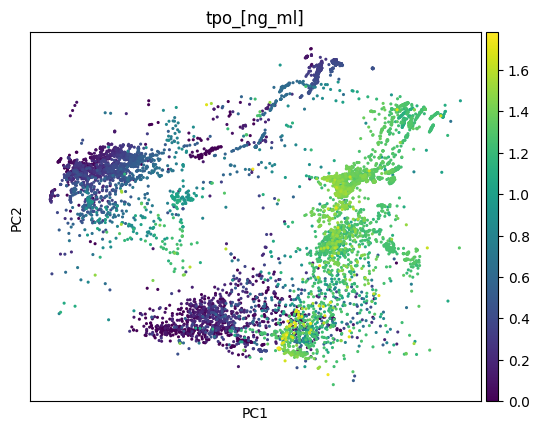

In [32]:
sc.pl.pca(adata_opt_solutions, color="tpo_[ng_ml]", s=20)

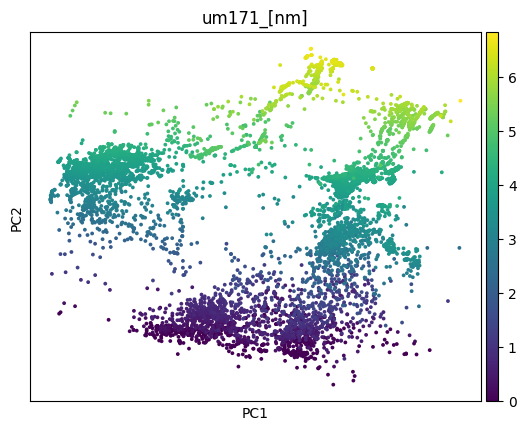

In [33]:
sc.pl.pca(adata_opt_solutions, color="um171_[nm]", s=30)

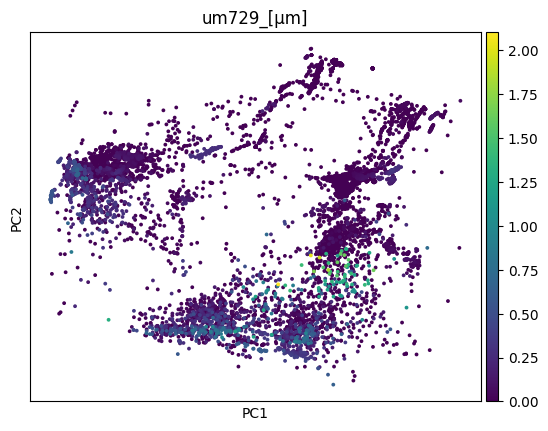

In [34]:
sc.pl.pca(adata_opt_solutions, color="um729_[µm]", s=30)

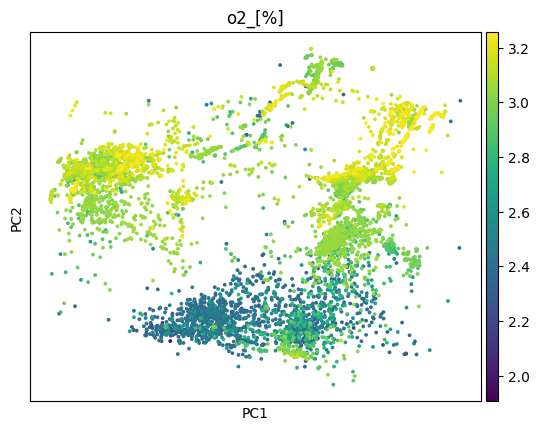

In [35]:
sc.pl.pca(adata_opt_solutions, color="o2_[%]", s=30)

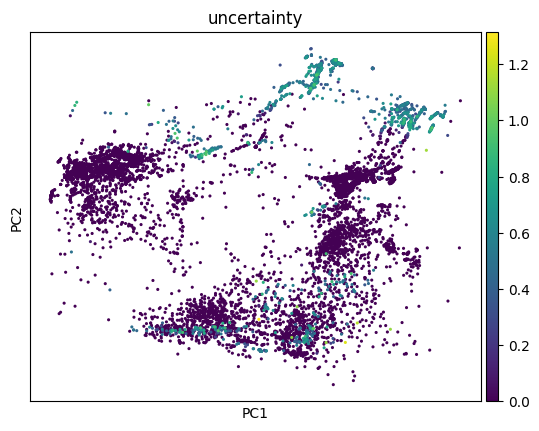

In [36]:
sc.pl.pca(adata_opt_solutions, color="uncertainty", s=20)

## Select options with opposite butyazemide and tpo

In [271]:
for cell_type in filtered_df:
    # Clean filtered data frames 
    filtered_df[cell_type]= filtered_df[cell_type].rename({"target_ct_loss_std": "uncertainty_loss", 
                                                           "ct_prop_total_variance": "uncertainty_total_variance_ct"}, 
                                                          axis=1)

    # Clean unfiltered dataframes 
    annotated_df[cell_type]= annotated_df[cell_type].rename({"target_ct_loss_std": "uncertainty_loss", 
                                                           "ct_prop_total_variance": "uncertainty_total_variance_ct"}, 
                                                          axis=1)

In [370]:
sakurai_medium = pd.DataFrame([0.0, 0.0, 0.0, 70, 0.0, 0.0, 100.0, 0.0, 0.0, 0.0, 20, 14, 0.0, 0.0]).T
sakurai_medium.columns = protocol_cols

mgkpro_df = filtered_df["late_MgkPro"].sort_values(by="uncertainty_loss")[:300]
mgkpro_df = pd.concat([mgkpro_df, sakurai_medium], axis=0).reset_index(drop=True)

In [371]:
mgkpro_df_log1p = np.log1p(mgkpro_df.loc[:, protocol_cols])

In [372]:
dist_mat = np.mean((mgkpro_df_log1p.values[None, :] - mgkpro_df_log1p.values[:, None])**2, axis=-1)

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/icb/alessandro.palma/miniconda3/envs/sc

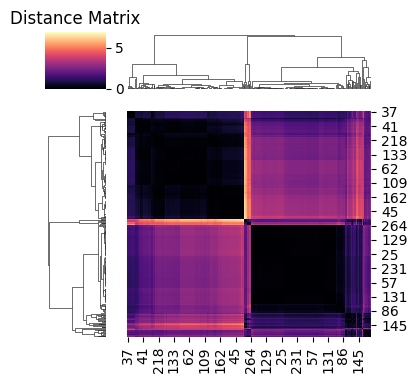

In [373]:
sns.clustermap(
    dist_mat,
    cmap="magma",   # choose any colormap you like
    square=True,
    annot=False,      # set True to show values
    cbar=True, 
    figsize=(4, 4)
)

plt.title("Distance Matrix")
plt.tight_layout()
plt.show()

In [374]:
def farthest_point_sampling(X, n_samples, start_idx=None):
    N = X.shape[0]

    if n_samples > N:
        raise ValueError("n_samples cannot exceed number of points")

    if start_idx is None:
        start_idx = np.random.randint(N)

    selected = np.empty(n_samples, dtype=int)
    selected[0] = start_idx

    # Distance from every point to nearest selected point
    min_distances = cdist(
        X,
        X[[start_idx]],
        metric="euclidean"
    ).squeeze()

    for i in range(1, n_samples):
        next_idx = np.argmax(min_distances)

        selected[i] = next_idx

        new_distances = cdist(
            X,
            X[[next_idx]],
            metric="euclidean"
        ).squeeze()

        min_distances = np.minimum(
            min_distances,
            new_distances
        )

    return selected

In [375]:
farthest_points = farthest_point_sampling(mgkpro_df_log1p.values, 5, start_idx=mgkpro_df_log1p.shape[0]-1)
farthest_points

array([300,  84,  30,  39, 102])

In [363]:
mgkpro_df.iloc[farthest_points].loc[:,  protocol_cols]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml]
300,0.000000,0.000000,0.000000,70.000000,0.0,0.000000,100.000000,0.000000,0.000000,0.000000,20.000000,14.000000,0.000000,0.000000
84,10.116817,1.760449,383.947270,0.219377,0.0,39.903473,0.504533,1.636096,0.212706,0.144901,9.688124,18.469175,6.458948,0.047935
30,6.190549,2.208225,29.554808,64.580320,0.0,40.224323,3.586962,0.119202,43.348515,0.349889,21.578545,13.510038,6.129765,1.490243
39,5.935072,0.000000,22.829487,0.000000,0.0,1.038136,21.918774,0.000000,0.000000,0.000000,9.736357,14.063212,0.000000,1.997599
102,11.993597,2.456602,417.769470,71.143105,0.0,0.836834,0.000000,0.000000,0.000000,0.000000,19.711523,13.303679,0.351802,0.142117


In [364]:
mgkpro_df.sort_values(by="tpo_[ng_ml]", ascending=False).loc[:, protocol_cols][:300]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml]
164,11.892087,3.624522,33.022762,43.381832,0.000000,6.635494,0.000000,0.000000,0.000000,0.000000,18.473808,13.262385,0.125547,0.246025
166,11.891500,3.624061,33.038086,43.369297,0.000000,6.636939,0.000000,0.000000,0.000000,0.000000,18.447477,13.260872,0.125069,0.246178
208,11.329309,3.532100,26.686430,45.531948,0.000000,7.363498,0.000000,0.000000,0.022991,0.000000,18.275946,12.447918,0.136945,0.244302
212,11.326641,3.530607,26.750143,45.548050,0.000000,7.374065,0.000000,0.000000,0.022869,0.000000,18.267340,12.444808,0.136728,0.244451
242,12.390581,3.492717,23.086508,39.734314,0.000000,6.900878,0.000000,0.000000,0.023181,0.000000,17.717762,13.425762,0.047913,0.675191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39,5.935072,0.000000,22.829487,0.000000,0.000000,1.038136,21.918774,0.000000,0.000000,0.000000,9.736357,14.063212,0.000000,1.997599
46,8.575668,0.000000,16.367897,0.000000,0.000000,2.767679,18.866674,0.179804,0.000000,0.000000,10.316344,14.442854,2.196623,0.058460
68,17.245565,0.000000,475.307340,0.000000,0.000000,26.147930,94.973550,0.000000,0.000000,0.000000,9.905060,18.151830,1.515597,0.699516
243,12.035141,0.000000,195.104540,0.318805,0.060242,19.510857,54.997350,0.191858,0.093223,0.135125,10.705716,17.980688,1.134248,0.207515


(array([119.,  35.,   8.,   1.,  12.,   4.,   5.,  38.,  33.,  46.]),
 array([0.        , 0.36245215, 0.7249043 , 1.08735645, 1.4498086 ,
        1.81226075, 2.1747129 , 2.53716505, 2.8996172 , 3.26206935,
        3.6245215 ]),
 <BarContainer object of 10 artists>)

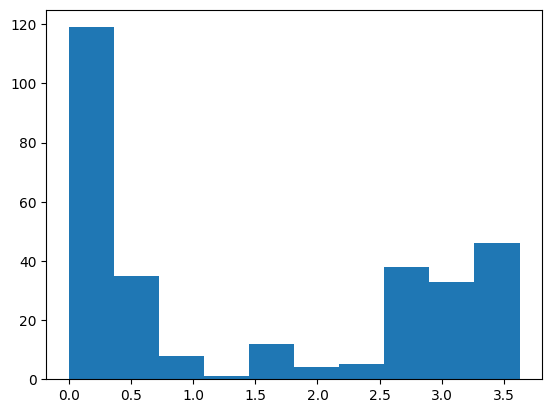

In [365]:
h = plt.hist(mgkpro_df["tpo_[ng_ml]"])
h

In [366]:
mgkpro_df.iloc[h[0]]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],...,days_of_culture,run_name,il7_[ng_ml],mcsf_[ng_ml],loss,uncertainty_loss,target_ct_loss_mean,uncertainty_total_variance_ct,late_MgkPro_prop,filtering_step
119,10.365994,2.923688,26.424824,46.354324,0.000000,7.901537,0.074507,0.000000,0.007384,0.000000,...,12.204200,penalized_oxy_days-pure_populations-reciprocal,0.041064,0.207297,1.885750,0.0,0.0,0.000873,0.843055,pass
35,10.389087,0.085173,0.000000,56.966540,0.000000,0.405653,67.885600,0.000000,0.014456,0.000000,...,15.825940,penalized_all_axes-pure_populations-reciprocal,0.000000,0.213167,2.467610,0.0,0.0,0.000466,0.845959,pass
8,0.445568,0.176298,0.000000,43.444637,0.595907,0.000000,73.949420,0.000000,0.000000,0.000000,...,14.397219,penalized_oxy_days-pure_populations-reciprocal,0.215968,0.000000,1.858081,0.0,0.0,0.000295,0.847241,pass
1,11.659342,0.104743,0.000000,46.655823,0.000000,0.332609,71.163130,0.000000,0.028334,0.003097,...,16.011020,penalized_oxy_days-pure_populations-reciprocal,0.000000,0.244932,2.338784,0.0,0.0,0.000562,0.847005,pass
12,17.351404,0.541033,19.797170,0.445252,0.000000,2.139377,0.000000,0.000000,0.000000,0.358575,...,13.373222,penalized_oxy_days-pure_populations-constant,0.745474,1.622283,1.677201,0.0,0.0,0.001015,0.847399,pass
4,0.394841,0.123856,0.000000,45.860435,0.645790,0.000000,76.501730,0.000000,0.000000,0.000000,...,14.856377,penalized_oxy_days-pure_populations-reciprocal,0.217804,0.000000,1.842453,0.0,0.0,0.000542,0.847079,pass
5,0.385200,0.123261,0.000000,45.929207,0.652233,0.000000,77.124530,0.000000,0.000000,0.000000,...,14.943080,penalized_oxy_days-pure_populations-reciprocal,0.218661,0.000000,1.841322,0.0,0.0,0.000324,0.847114,pass
38,3.678364,0.303556,0.000000,36.621166,0.089042,0.474357,55.772440,0.000000,0.000000,0.050222,...,12.631569,penalized_oxy_days-pure_populations-reciprocal,0.041303,0.000000,1.751445,0.0,0.0,0.000237,0.846023,pass
33,12.379957,0.106678,0.000000,45.558784,0.000000,0.312515,71.395630,0.000000,0.030820,0.001894,...,16.319902,penalized_oxy_days-pure_populations-reciprocal,0.000000,0.260462,2.377912,0.0,0.0,0.000483,0.845856,pass
46,8.575668,0.000000,16.367897,0.000000,0.000000,2.767679,18.866674,0.179804,0.000000,0.000000,...,14.442854,penalized_oxy_days-pure_populations-constant,2.196623,0.058460,1.572661,0.0,0.0,0.000210,0.846479,pass


## Check bins

In [367]:
counts, bin_edges, _ = h

# Get bin index for each row (1-indexed, so subtract 1)
bin_indices = np.digitize(mgkpro_df["tpo_[ng_ml]"], bin_edges) - 1

# Clip to valid range [0, num_bins-1] to handle values on the right edge
num_bins = len(counts)
bin_indices = np.clip(bin_indices, 0, num_bins - 1)

# Group row indices per bin
indices_per_bin = {i: np.where(bin_indices == i)[0].tolist() for i in range(num_bins)}

In [392]:
selected_per_bins = []
for key in list(indices_per_bin.keys())[-5:]:
    print(key)
    selected_per_bins.append(np.random.choice(indices_per_bin[key], 5))
    # print(mgkpro_df.iloc[indices_per_bin[key]].loc[:, protocol_cols])
    # print()

selected_per_bins = np.concatenate(selected_per_bins)

5
6
7
8
9


In [395]:
mgkpro_df.iloc[selected_per_bins].loc[:, protocol_cols]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml]
101,10.076756,1.880622,28.573875,2.322670,0.000000,7.938710,0.213124,0.000000,0.001881,0.011113,10.840066,12.147219,1.389719,0.013497
73,11.401025,1.938043,133.299330,0.000000,0.000000,51.870583,0.315022,1.440425,0.249634,0.352292,9.843935,13.943146,12.755812,0.000000
73,11.401025,1.938043,133.299330,0.000000,0.000000,51.870583,0.315022,1.440425,0.249634,0.352292,9.843935,13.943146,12.755812,0.000000
73,11.401025,1.938043,133.299330,0.000000,0.000000,51.870583,0.315022,1.440425,0.249634,0.352292,9.843935,13.943146,12.755812,0.000000
27,7.560704,1.814652,39.764700,1.829272,0.287094,32.834340,0.513322,0.048471,0.135144,0.341606,12.514917,12.289004,4.743205,0.079479
280,10.115875,2.479587,182.913420,0.000000,0.000000,24.351210,0.397456,1.323982,0.520390,0.377295,9.593521,18.370468,9.269617,0.226183
185,10.775205,2.515900,41.199670,110.935165,0.000000,20.097408,0.000000,0.000000,0.000000,0.014745,23.865166,14.016676,1.439157,0.000000
102,11.993597,2.456602,417.769470,71.143105,0.000000,0.836834,0.000000,0.000000,0.000000,0.000000,19.711523,13.303679,0.351802,0.142117
30,6.190549,2.208225,29.554808,64.580320,0.000000,40.224323,3.586962,0.119202,43.348515,0.349889,21.578545,13.510038,6.129765,1.490243
185,10.775205,2.515900,41.199670,110.935165,0.000000,20.097408,0.000000,0.000000,0.000000,0.014745,23.865166,14.016676,1.439157,0.000000


In [398]:
mgkpro_df.iloc[selected_per_bins].to_csv("../../../../../../project_folder/output/inverse/loss_guidance/manually_filtered/results_loop3/tpo_folder/high_tpo_low_um171.csv")